In [185]:
path = r".\\ames.csv"

# Ames House Price Analysis

## 1. Importing Libraries

In [186]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os 

In [187]:
os.makedirs("images" ,exist_ok=True)

## 2. Loading the Dataset

In [188]:
df = pd.read_csv(path)

## 3. Initial Data Inspection

In [189]:
df.shape

(2930, 81)

In [190]:
df.columns.tolist()

['MS_SubClass',
 'MS_Zoning',
 'Lot_Frontage',
 'Lot_Area',
 'Street',
 'Alley',
 'Lot_Shape',
 'Land_Contour',
 'Utilities',
 'Lot_Config',
 'Land_Slope',
 'Neighborhood',
 'Condition_1',
 'Condition_2',
 'Bldg_Type',
 'House_Style',
 'Overall_Qual',
 'Overall_Cond',
 'Year_Built',
 'Year_Remod_Add',
 'Roof_Style',
 'Roof_Matl',
 'Exterior_1st',
 'Exterior_2nd',
 'Mas_Vnr_Type',
 'Mas_Vnr_Area',
 'Exter_Qual',
 'Exter_Cond',
 'Foundation',
 'Bsmt_Qual',
 'Bsmt_Cond',
 'Bsmt_Exposure',
 'BsmtFin_Type_1',
 'BsmtFin_SF_1',
 'BsmtFin_Type_2',
 'BsmtFin_SF_2',
 'Bsmt_Unf_SF',
 'Total_Bsmt_SF',
 'Heating',
 'Heating_QC',
 'Central_Air',
 'Electrical',
 'First_Flr_SF',
 'Second_Flr_SF',
 'Low_Qual_Fin_SF',
 'Gr_Liv_Area',
 'Bsmt_Full_Bath',
 'Bsmt_Half_Bath',
 'Full_Bath',
 'Half_Bath',
 'Bedroom_AbvGr',
 'Kitchen_AbvGr',
 'Kitchen_Qual',
 'TotRms_AbvGrd',
 'Functional',
 'Fireplaces',
 'Fireplace_Qu',
 'Garage_Type',
 'Garage_Finish',
 'Garage_Cars',
 'Garage_Area',
 'Garage_Qual',
 'Garage

In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MS_SubClass         2930 non-null   object 
 1   MS_Zoning           2930 non-null   object 
 2   Lot_Frontage        2930 non-null   int64  
 3   Lot_Area            2930 non-null   int64  
 4   Street              2930 non-null   object 
 5   Alley               2930 non-null   object 
 6   Lot_Shape           2930 non-null   object 
 7   Land_Contour        2930 non-null   object 
 8   Utilities           2930 non-null   object 
 9   Lot_Config          2930 non-null   object 
 10  Land_Slope          2930 non-null   object 
 11  Neighborhood        2930 non-null   object 
 12  Condition_1         2930 non-null   object 
 13  Condition_2         2930 non-null   object 
 14  Bldg_Type           2930 non-null   object 
 15  House_Style         2930 non-null   object 
 16  Overal

## 4. Missing Values Analysis

In [192]:
missing = df.isna().sum()
missing[missing>0].sort_values(ascending = False)

Misc_Feature    2824
Mas_Vnr_Type    1775
dtype: int64

In [193]:
df["Misc_Feature"].value_counts(dropna = False)

Misc_Feature
NaN     2824
Shed      95
Gar2       5
Othr       4
Elev       1
TenC       1
Name: count, dtype: int64

In [194]:
df["Mas_Vnr_Type"].value_counts(dropna = False)

Mas_Vnr_Type
NaN        1775
BrkFace     880
Stone       249
BrkCmn       25
CBlock        1
Name: count, dtype: int64

In [195]:
df.isna().sum().sum()

np.int64(4599)

In [196]:
missing

MS_SubClass       0
MS_Zoning         0
Lot_Frontage      0
Lot_Area          0
Street            0
                 ..
Sale_Type         0
Sale_Condition    0
Sale_Price        0
Longitude         0
Latitude          0
Length: 81, dtype: int64

In [197]:
missing_percent = (df.isna().sum() / len(df) )* 100

missing_percent[missing_percent > 0].sort_values(ascending =False)

Misc_Feature    96.382253
Mas_Vnr_Type    60.580205
dtype: float64

## 5. Handling Missing Values

Missing values in `Misc_Feature` and `Mas_Vnr_Type` were replaced with `"None"` because the missing value represents the absence of that feature.


In [198]:
df_clean = df.copy()

In [199]:
df_clean["Misc_Feature"] = df_clean["Misc_Feature"].fillna("None")
df_clean["Mas_Vnr_Type"] = df_clean["Mas_Vnr_Type"].fillna("None")

In [200]:
df_clean.isna().sum()[df_clean.isna().sum()>0]

Series([], dtype: int64)

## 6. Basic Data Quality Checks

In [201]:
df_clean.duplicated().sum()

np.int64(0)

In [202]:
df_clean.dtypes.value_counts()

object     46
int64      33
float64     2
Name: count, dtype: int64

In [203]:
df_clean.describe()

,Lot_Frontage,Lot_Area,Year_Built,Year_Remod_Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,First_Flr_SF,...,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Misc_Val,Mo_Sold,Year_Sold,Sale_Price,Longitude,Latitude
count,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,57.647782,10147.921843,1971.356314,1984.266553,101.096928,4.177474,49.705461,559.071672,1051.255631,1159.557679,...,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068,-93.642897,42.034482
std,33.499441,7880.017759,30.245361,20.860286,178.634545,2.233372,169.142089,439.540571,440.968018,391.890885,...,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357,0.025700,0.018410
min,0.000000,1300.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000,-93.693153,41.986498
25%,43.000000,7440.250000,1954.000000,1965.000000,0.000000,3.000000,0.000000,219.000000,793.000000,876.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000,-93.660217,42.022088
50%,63.000000,9436.500000,1973.000000,1993.000000,0.000000,3.000000,0.000000,465.500000,990.000000,1084.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000,-93.641806,42.034662
75%,78.000000,11555.250000,2001.000000,2004.000000,162.750000,7.000000,0.000000,801.750000,1301.500000,1384.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000,-93.622113,42.049853
max,313.000000,215245.000000,2010.000000,2010.000000,1600.000000,7.000000,1526.000000,2336.000000,6110.000000,5095.000000,...,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000,-93.577427,42.063388


## 7. Handling Invalid Values in Lot_Frontage

In [204]:
(df_clean["Lot_Frontage"]==0).sum()

np.int64(490)

In [205]:
df_clean[df_clean["Lot_Frontage"]==0][["Lot_Frontage","Lot_Area" ,"Lot_Shape" ,"Neighborhood" ,"Sale_Price"]].head(10)

,Lot_Frontage,Lot_Area,Lot_Shape,Neighborhood,Sale_Price
11,0,7980,Slightly_Irregular,Gilbert,185000
14,0,6820,Slightly_Irregular,Stone_Brook,212000
22,0,7500,Regular,Somerset,216000
23,0,11241,Slightly_Irregular,North_Ames,149000
24,0,12537,Slightly_Irregular,North_Ames,149900
55,0,7851,Regular,Gilbert,216500
57,0,7750,Slightly_Irregular,Gilbert,180000
58,0,9505,Slightly_Irregular,Gilbert,222500
74,0,8880,Slightly_Irregular,Sawyer_West,205000
79,0,9453,Slightly_Irregular,Sawyer_West,194500


In [206]:
df_clean[df_clean["Lot_Frontage"] ==0]["Neighborhood"].value_counts()

Neighborhood
North_Ames                                 68
Gilbert                                    54
Sawyer                                     53
College_Creek                              47
Northwest_Ames                             46
Clear_Creek                                24
Mitchell                                   24
Somerset                                   20
Crawford                                   20
Sawyer_West                                19
Northridge                                 17
Edwards                                    16
Timberland                                 15
Brookside                                  13
Old_Town                                   10
Veenker                                     8
Bloomington_Heights                         8
Iowa_DOT_and_Rail_Road                      6
Stone_Brook                                 5
South_and_West_of_Iowa_State_University     4
Meadow_Village                              4
Northridge_Heights   

In [207]:
df_clean.loc[df_clean["Lot_Frontage"] == 0 , "Lot_Frontage"] = np.nan

# Convert zero values to NaN because a lot frontage of 0 is treated as a missing value.

In [208]:
df_clean["Lot_Frontage"].isna().sum()

np.int64(490)

In [209]:
df_clean["Lot_Frontage"].describe()

count    2440.000000
mean       69.224590
std        23.365335
min        21.000000
25%        58.000000
50%        68.000000
75%        80.000000
max       313.000000
Name: Lot_Frontage, dtype: float64

In [210]:
df_clean["Lot_Frontage"] = df_clean["Lot_Frontage"].fillna(df_clean["Lot_Frontage"].median())

# Fill missing Lot_Frontage values with the median.

## 8. Data Consistency Checks

In [211]:
(df_clean["Sale_Price"] <= 0).sum()

np.int64(0)

In [212]:
(df_clean["Lot_Area"] <= 0).sum()

np.int64(0)

In [213]:
(df_clean["Year_Built"] > df_clean["Year_Sold"]).sum()

np.int64(1)

In [214]:
df_clean.loc[df_clean["Year_Built"] > df_clean["Year_Sold"] , ["Year_Built" ,"Year_Sold" ,"Sale_Price" ,"Neighborhood"]]

,Year_Built,Year_Sold,Sale_Price,Neighborhood
2180,2008,2007,183850,Edwards


In [215]:
df_clean[df_clean["Neighborhood"] =="Edwards"][["Year_Built" ,"Year_Sold" ,"Sale_Price"]].describe()

,Year_Built,Year_Sold,Sale_Price
count,194.000000,194.000000,194.000000
mean,1956.938144,2007.798969,130843.381443
std,26.166392,1.325634,48030.405046
min,1900.000000,2006.000000,35000.000000
25%,1941.000000,2007.000000,103525.000000
50%,1954.000000,2008.000000,125000.000000
75%,1971.250000,2009.000000,144875.000000
max,2009.000000,2010.000000,415000.000000


## 9. Sale Price Distribution

In [216]:
df_clean["Sale_Price"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

0.01     61756.07
0.05     87500.00
0.25    129500.00
0.50    160000.00
0.75    213500.00
0.95    335000.00
0.99    456666.37
Name: Sale_Price, dtype: float64

## 10. Feature Engineering

### 10.1 House Age

In [217]:
df_clean["House_age"] = df_clean["Year_Sold"] - df_clean["Year_Built"]

In [218]:
df_clean[["House_age" , "Year_Sold" ,"Year_Built"]].head()

,House_age,Year_Sold,Year_Built
0,50,2010,1960
1,49,2010,1961
2,52,2010,1958
3,42,2010,1968
4,13,2010,1997


### 10.2 Price per Square Foot

In [219]:
df_clean["Price_Per_Sq_Ft"] = df_clean["Sale_Price"] / df_clean["Gr_Liv_Area"]

In [220]:
df_clean[["Price_Per_Sq_Ft" ,"Sale_Price" ,"Gr_Liv_Area"]].head()

,Price_Per_Sq_Ft,Sale_Price,Gr_Liv_Area
0,129.830918,215000,1656
1,117.187500,105000,896
2,129.420617,172000,1329
3,115.639810,244000,2110
4,116.574586,189900,1629


### 10.3 Converting Overall Quality to Numeric Values

In [221]:
df_clean["Overall_Qual"].dtypes

dtype('O')

In [222]:
df_clean["Overall_Qual"].value_counts()

Overall_Qual
Average           825
Above_Average     732
Good              602
Very_Good         350
Below_Average     226
Excellent         107
Fair               40
Very_Excellent     31
Poor               13
Very_Poor           4
Name: count, dtype: int64

In [223]:
quality_map = {
    "Very_Poor": 1,
    "Poor": 2,
    "Fair": 3,
    "Below_Average": 4,
    "Average": 5,
    "Above_Average": 6,
    "Good": 7,
    "Very_Good": 8,
    "Excellent": 9,
    "Very_Excellent": 10
}

In [224]:
df_clean["Overall_Qual_Num"] = df_clean["Overall_Qual"].map(quality_map)

### 10.4 Luxury House Classification

In [225]:
df_clean["Luxury_House"] = np.where(df_clean["Overall_Qual_Num"] >= 8 , True ,False)

In [226]:
df_clean[["Overall_Qual" ,"Overall_Qual_Num"]]

,Overall_Qual,Overall_Qual_Num
0,Above_Average,6
1,Average,5
2,Above_Average,6
3,Good,7
4,Average,5
...,...,...
2925,Above_Average,6
2926,Average,5
2927,Average,5
2928,Average,5


In [227]:
df_clean["Luxury_House"].value_counts()

Luxury_House
False    2442
True      488
Name: count, dtype: int64

### 10.5 Price Category

In [228]:
conditions = [ 
    df_clean["Sale_Price"] < 100000 ,
    df_clean["Sale_Price"] < 200000 , 
    df_clean["Sale_Price"] < 300000 
]

choices = [
    "Budget" , "Mid_Range" , "High"]

df_clean["Price_Category"] = np.select(
    conditions , choices , default = "Luxury")

In [229]:
df_clean["Price_Category"].value_counts()

Price_Category
Mid_Range    1817
High          638
Luxury        238
Budget        237
Name: count, dtype: int64

### 10.6 Total Bathrooms

In [230]:
df_clean["Total_Bathrooms"] = (df_clean["Half_Bath"] * 0.5 + df_clean["Full_Bath"])

In [231]:
df_clean[["Total_Bathrooms" ,"Half_Bath" ,"Full_Bath"]]

,Total_Bathrooms,Half_Bath,Full_Bath
0,1.0,0,1
1,1.0,0,1
2,1.5,1,1
3,2.5,1,2
4,2.5,1,2
...,...,...,...
2925,1.0,0,1
2926,1.0,0,1
2927,1.0,0,1
2928,1.0,0,1


### 10.7 Renovation Status

In [232]:
df_clean["Is_Renovated"] = (df_clean["Year_Remod_Add"] > df_clean["Year_Built"])

In [233]:
df_clean["Is_Renovated"].head()

0    False
1    False
2    False
3    False
4     True
Name: Is_Renovated, dtype: bool

In [234]:
df_clean["Is_Renovated"].value_counts()

Is_Renovated
False    1570
True     1360
Name: count, dtype: int64

## 11. Exploratory Data Analysis

In [235]:
df_clean["Sale_Price"].mean()

np.float64(180796.0600682594)

In [236]:
df_clean["Sale_Price"].median()

160000.0

### 11.1 Sale Price by Neighborhood

In [237]:
df_clean.groupby("Neighborhood")["Sale_Price"].mean()

Neighborhood
Bloomington_Heights                        196661.678571
Blueste                                    143590.000000
Briardale                                  105608.333333
Brookside                                  124756.250000
Clear_Creek                                208662.090909
College_Creek                              201803.434457
Crawford                                   207550.834951
Edwards                                    130843.381443
Gilbert                                    190646.575758
Green_Hills                                280000.000000
Greens                                     193531.250000
Iowa_DOT_and_Rail_Road                     103752.903226
Landmark                                   137000.000000
Meadow_Village                              95756.486486
Mitchell                                   162226.631579
North_Ames                                 145097.349887
Northpark_Villa                            140710.869565
Northridge        

In [238]:
df_clean.groupby("Neighborhood")["Sale_Price"].agg(["mean" ,"count"]).sort_values("mean" ,ascending = False)

,mean,count
Neighborhood,,
Northridge,330319.126761,71
Stone_Brook,324229.196078,51
Northridge_Heights,322018.265060,166
Green_Hills,280000.000000,2
Veenker,248314.583333,24
Timberland,246599.541667,72
Somerset,229707.324176,182
Clear_Creek,208662.090909,44
Crawford,207550.834951,103


### 11.2 Living Area and Sale Price

In [239]:
df_clean[["Gr_Liv_Area" , "Sale_Price"]].head(10)

,Gr_Liv_Area,Sale_Price
0,1656,215000
1,896,105000
2,1329,172000
3,2110,244000
4,1629,189900
5,1604,195500
6,1338,213500
7,1280,191500
8,1616,236500
9,1804,189000


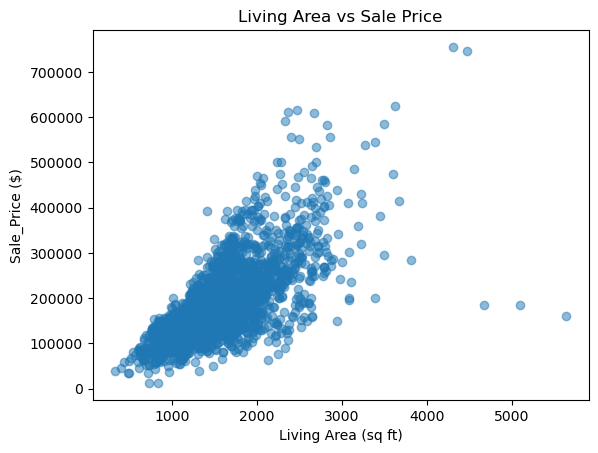

In [240]:
plt.figure()
plt.scatter(df_clean["Gr_Liv_Area"] , df_clean["Sale_Price"], alpha=0.5)
plt.title("Living Area vs Sale Price")
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Sale_Price ($)")
plt.savefig("images/living_area_vs_price.png" ,bbox_inches="tight" ,dpi = 300)
plt.show()

### Insight

Larger living areas are generally associated with higher sale prices, although the relationship is not perfectly linear.

In [241]:
df_clean["Gr_Liv_Area"].corr(df_clean["Sale_Price"])

np.float64(0.7067799209766279)

### 11.3 Overall Quality and Sale Price

In [242]:
df_clean["Sale_Price"].corr(df_clean["Overall_Qual_Num"])

np.float64(0.7992617947690228)

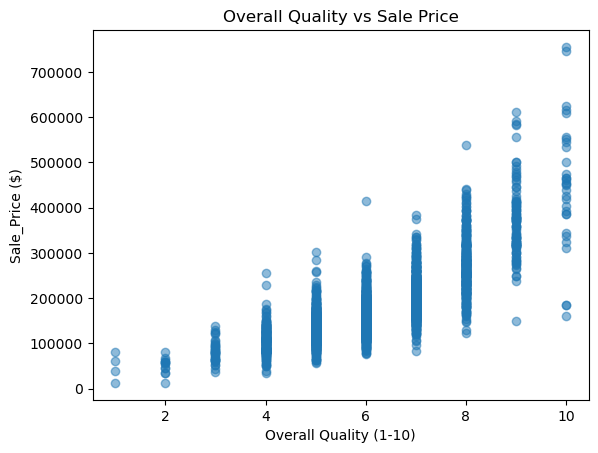

In [243]:
plt.scatter(df_clean["Overall_Qual_Num"] ,df_clean["Sale_Price"] ,alpha=0.5)
plt.xlabel("Overall Quality (1-10)")
plt.ylabel("Sale_Price ($)")
plt.title("Overall Quality vs Sale Price")
plt.savefig("images/overall_quality_vs_price.png" ,bbox_inches="tight" ,dpi = 300)
plt.show()

### Insight

Higher overall quality is strongly associated with higher sale prices.

### 11.4 House Age and Sale Price

In [244]:
df_clean["House_age"].corr(df_clean["Sale_Price"])

np.float64(-0.5589068324589406)

### 11.5 Number of Rooms and Sale Price

In [245]:
df_clean["TotRms_AbvGrd"].corr(df_clean["Sale_Price"])

np.float64(0.4954744168570346)

### 11.6 Average Sale Price by Year

In [246]:
avg_yearly_price = df_clean.groupby("Year_Sold")["Sale_Price"].mean()

In [247]:
yearly_price

Year_Sold
2006    181761.648000
2007    185138.207493
2008    178841.750804
2009    181404.567901
2010    172597.598240
Name: Sale_Price, dtype: float64

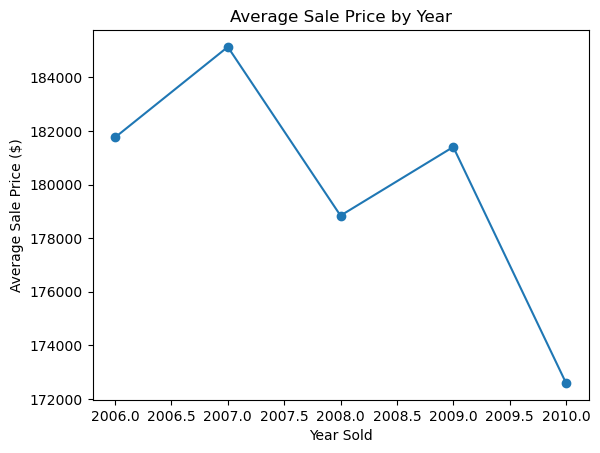

In [248]:
plt.plot(yearly_price.index , yearly_price.values ,marker = "o")
plt.xlabel("Year Sold")
plt.ylabel("Average Sale Price ($)")
plt.title("Average Sale Price by Year")
plt.savefig("images/avg_price_by_year.png" ,bbox_inches="tight" ,dpi = 300)
plt.show()

### Insight

Average sale prices were highest in 2007 and lowest in 2010, with some fluctuations across the years.

### 11.7 Average Sale Price by Number of Rooms

In [249]:
room_price = df_clean.groupby("TotRms_AbvGrd")["Sale_Price"].agg(["mean" ,"count"])

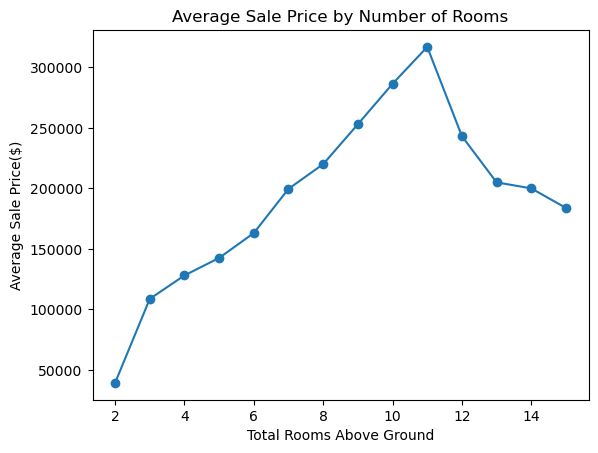

In [250]:
plt.plot(room_price.index, room_price["mean"], marker="o")
plt.xlabel("Total Rooms Above Ground")
plt.ylabel("Average Sale Price($)")
plt.title("Average Sale Price by Number of Rooms")
plt.savefig("images/price_by_rooms.png" ,bbox_inches="tight" ,dpi = 300)
plt.show()

### Insight

Average sale price generally increases as the number of rooms increases, although the trend becomes less consistent for homes with very large numbers of rooms.

In [251]:
room_price

,mean,count
TotRms_AbvGrd,,
2,39300.000000,1
3,108715.384615,26
4,128106.000000,203
5,142555.269625,586
6,163129.086493,844
7,199646.898305,649
8,220044.850144,347
9,253019.853147,143
10,286435.462500,80


### 11.8 Average Sale Price by Overall Quality

In [252]:
df_clean.groupby("Overall_Qual_Num")["Sale_Price"].agg(["mean" ,"count"])

,mean,count
Overall_Qual_Num,,
1,48725.000000,4
2,52325.307692,13
3,83185.975000,40
4,106485.097345,226
5,134752.516364,825
6,162130.318306,732
7,205025.760797,602
8,270913.594286,350
9,368336.766355,107


### 11.9 Price per Square Foot by Neighborhood

In [253]:
df_clean.groupby("Neighborhood")["Price_Per_Sq_Ft"].agg(["mean" ,"count"]).sort_values("mean" , ascending = False)

,mean,count
Neighborhood,,
Green_Hills,198.656617,2
Greens,168.835142,8
Stone_Brook,166.063367,51
Northridge_Heights,165.565534,166
Timberland,144.740459,72
Somerset,143.672789,182
Veenker,143.231669,24
Bloomington_Heights,140.088760,28
College_Creek,137.370426,267


## 12. Outlier Analysis

### 12.1 Extreme Price per Square Foot

In [254]:
df_clean["Sale_Price"].max()

755000

In [255]:
df_clean.nlargest(10 ,"Price_Per_Sq_Ft")[["Price_Per_Sq_Ft" ,"Sale_Price" ,"Gr_Liv_Area" ,"Overall_Qual_Num" ,"Neighborhood"]]

,Price_Per_Sq_Ft,Sale_Price,Gr_Liv_Area,Overall_Qual_Num,Neighborhood
1640,276.250881,392000,1419,8,Stone_Brook
44,258.738156,611657,2364,9,Northridge_Heights
1637,253.031223,591587,2338,9,Stone_Brook
1063,248.987854,615000,2470,10,Northridge_Heights
1559,237.590799,392500,1652,8,Crawford
2341,235.000000,470000,2000,9,Stone_Brook
423,231.057452,555000,2402,10,Northridge_Heights
2245,230.769231,375000,1625,8,Crawford
432,228.122663,610000,2674,10,Northridge_Heights
366,224.636079,501837,2234,9,Stone_Brook


### 12.2 Investigating Unusual Properties

In [256]:
df_clean.nsmallest(10 ,"Price_Per_Sq_Ft")[["Price_Per_Sq_Ft" ,"Sale_Price" ,"Gr_Liv_Area" ,"Overall_Qual_Num" ,"Neighborhood"]]

,Price_Per_Sq_Ft,Sale_Price,Gr_Liv_Area,Overall_Qual_Num,Neighborhood
181,15.371394,12789,832,2,Old_Town
1553,17.871760,13100,733,1,Iowa_DOT_and_Rail_Road
1498,28.358738,160000,5642,10,Edwards
753,29.370301,62500,2128,5,Old_Town
1555,30.372058,40000,1317,4,Iowa_DOT_and_Rail_Road
2043,33.692722,50000,1484,4,Iowa_DOT_and_Rail_Road
186,33.909574,76500,2256,5,Old_Town
2180,36.084396,183850,5095,10,Edwards
1993,38.510911,90000,2337,5,Old_Town
709,39.152893,37900,968,3,Old_Town


In [257]:
df_clean["Gr_Liv_Area"].mean()

np.float64(1499.6904436860068)

In [258]:
df_clean["Gr_Liv_Area"].median()

1442.0

In [259]:
df_clean["Gr_Liv_Area"].max()

5642

In [260]:
df_clean.loc[df_clean["Gr_Liv_Area"] == 5642]

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Sale_Price,Longitude,Latitude,House_age,Price_Per_Sq_Ft,Overall_Qual_Num,Luxury_House,Price_Category,Total_Bathrooms,Is_Renovated
1498,Two_Story_1946_and_Newer,Residential_Low_Density,313.0,63887,Pave,No_Alley_Access,Irregular,Bnk,AllPub,Corner,...,160000,-93.674898,42.016804,0,28.358738,10,True,Mid_Range,2.5,False


In [261]:
df_clean[df_clean["Overall_Qual_Num"]==10][["Sale_Price" ,"Price_Per_Sq_Ft" ,"Neighborhood" ,"Gr_Liv_Area"]].sort_values("Gr_Liv_Area" ,ascending = False)

,Sale_Price,Price_Per_Sq_Ft,Neighborhood,Gr_Liv_Area
1498,160000,28.358738,Edwards,5642
2180,183850,36.084396,Edwards,5095
2181,184750,39.510265,Edwards,4676
1760,745000,166.443253,Northridge,4476
1767,755000,174.930491,Northridge,4316
2445,625000,172.318721,Northridge,3627
2666,475000,131.651885,Old_Town,3608
2330,545224,160.833038,Stone_Brook,3390
2336,438780,148.991511,Stone_Brook,2945
1059,460000,164.874552,Northridge_Heights,2790


In [262]:
df_clean[(df_clean["Overall_Qual_Num"]==10) & (df_clean["Neighborhood"]== "Edwards")][["Sale_Price" ,"Price_Per_Sq_Ft" ,"Neighborhood" ,"Gr_Liv_Area" ,"Year_Built" ,"Year_Sold" ]].sort_values("Gr_Liv_Area" ,ascending = False)

,Sale_Price,Price_Per_Sq_Ft,Neighborhood,Gr_Liv_Area,Year_Built,Year_Sold
1498,160000,28.358738,Edwards,5642,2008,2008
2180,183850,36.084396,Edwards,5095,2008,2007
2181,184750,39.510265,Edwards,4676,2007,2007


In [263]:
df_clean[(df_clean["Overall_Qual_Num"]==10) & (df_clean["Neighborhood"]== "Edwards")].T

,1498,2180,2181
MS_SubClass,Two_Story_1946_and_Newer,One_Story_1946_and_Newer_All_Styles,Two_Story_1946_and_Newer
MS_Zoning,Residential_Low_Density,Residential_Low_Density,Residential_Low_Density
Lot_Frontage,313.0,128.0,130.0
Lot_Area,63887,39290,40094
Street,Pave,Pave,Pave
...,...,...,...
Overall_Qual_Num,10,10,10
Luxury_House,True,True,True
Price_Category,Mid_Range,Mid_Range,Mid_Range
Total_Bathrooms,2.5,2.5,3.5


In [264]:
df_clean.loc[(df_clean["Overall_Qual_Num"]==10) & (df_clean["Neighborhood"]== "Edwards"),["Sale_Price" ,"Price_Per_Sq_Ft" ,"Neighborhood" ,"Gr_Liv_Area" ,"Year_Built" ,"Year_Sold" ]]

,Sale_Price,Price_Per_Sq_Ft,Neighborhood,Gr_Liv_Area,Year_Built,Year_Sold
1498,160000,28.358738,Edwards,5642,2008,2008
2180,183850,36.084396,Edwards,5095,2008,2007
2181,184750,39.510265,Edwards,4676,2007,2007


In [265]:
df_clean[df_clean["Year_Sold"] < df_clean["Year_Built"]]

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Sale_Price,Longitude,Latitude,House_age,Price_Per_Sq_Ft,Overall_Qual_Num,Luxury_House,Price_Category,Total_Bathrooms,Is_Renovated
2180,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,128.0,39290,Pave,No_Alley_Access,Slightly_Irregular,Bnk,AllPub,Inside,...,183850,-93.67622,42.016453,-1,36.084396,10,True,Mid_Range,2.5,True


In [266]:
df_clean.loc[df_clean.index.isin([1498 ,2180 ,2181]) ,["Sale_Price" ,"Sale_Condition"]]

,Sale_Price,Sale_Condition
1498,160000,Partial
2180,183850,Partial
2181,184750,Partial



The cleaned dataset was loaded into a SQLite database to perform SQL-based analysis.

## 13. SQL Analysis

In [267]:
import sqlite3

conn = sqlite3.connect("house_prices.db")

df_clean.to_sql("houses", conn, if_exists="replace", index=False)

2930

### 13.1 Top Neighborhoods by Average Sale Price

In [268]:
query = """
SELECT
    Neighborhood,
    AVG(Sale_Price) AS Avg_Sale_Price
FROM houses
GROUP BY Neighborhood
ORDER BY Avg_Sale_Price DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,Neighborhood,Avg_Sale_Price
0,Northridge,330319.126761
1,Stone_Brook,324229.196078
2,Northridge_Heights,322018.265060
3,Green_Hills,280000.000000
4,Veenker,248314.583333
5,Timberland,246599.541667
6,Somerset,229707.324176
7,Clear_Creek,208662.090909
8,Crawford,207550.834951
9,College_Creek,201803.434457


### 13.2 Most Expensive Properties

In [269]:
query = """
SELECT
    Neighborhood,
    Sale_Price
FROM houses
ORDER BY Sale_Price desc
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,Neighborhood,Sale_Price
0,Northridge,755000
1,Northridge,745000
2,Northridge,625000
3,Northridge_Heights,615000
4,Northridge_Heights,611657
5,Northridge_Heights,610000
6,Stone_Brook,591587
7,Northridge,584500
8,Northridge_Heights,582933
9,Stone_Brook,556581


### 13.3 Low-Priced Properties with High Overall Quality

In [270]:
query = """
SELECT Overall_Qual_Num , Sale_Price
FROM houses 
WHERE Overall_Qual_Num >= 8
ORDER BY Sale_Price asc
LIMIT 10 
"""

result = pd.read_sql_query(query , conn)

result

,Overall_Qual_Num,Sale_Price
0,8,122000
1,8,130000
2,8,147000
3,8,150000
4,9,150000
5,8,155000
6,10,160000
7,8,161000
8,8,162500
9,8,164000


# 14. Key Insights

- Overall quality has the strongest positive relationship with Sale Price among the variables analyzed.
- Larger living areas are generally associated with higher sale prices.
- House age has a negative relationship with Sale Price, meaning older houses tend to sell for lower prices.
- Sale prices vary considerably across neighborhoods, with Northridge, Stone_Brook, and Northridge_Heights among the highest-priced neighborhoods.
- The average sale price generally increases as the number of rooms increases, although the relationship becomes less consistent for homes with very large numbers of rooms.
- The analysis also identified unusual properties, including high-quality houses with unusually low prices and one record where the sale year is earlier than the construction year.

# 15. Conclusion

This project explored the Ames housing dataset using Python, Pandas, NumPy, and SQL. 
The analysis included data cleaning, feature engineering, exploratory data analysis, and identification of unusual observations.